In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency, mannwhitneyu, skew, kurtosis

plt.style.use("default")
sns.set(style="whitegrid")

# Load data
spotify_df = pd.read_csv("spotify_churn_dataset.csv")

# Create a clearer churn column alias
spotify_df["churn_flag"] = spotify_df["is_churned"]

spotify_df.head()

,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned,churn_flag
0,1,Female,54,CA,Free,26,23,0.20,Desktop,31,0,1,1
1,2,Other,33,DE,Family,141,62,0.34,Web,0,1,0,0
2,3,Male,38,AU,Premium,199,38,0.04,Mobile,0,1,1,1
3,4,Female,22,CA,Student,36,2,0.31,Mobile,0,1,0,0
4,5,Other,29,US,Family,250,57,0.36,Mobile,0,1,1,1


**Overview**

In [2]:
print(spotify_df.shape)
print()
print(spotify_df.info())
print()
display(spotify_df.describe())

print("\nMissing values:")
print(spotify_df.isnull().sum())

(8000, 13)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                8000 non-null   int64  
 1   gender                 8000 non-null   object 
 2   age                    8000 non-null   int64  
 3   country                8000 non-null   object 
 4   subscription_type      8000 non-null   object 
 5   listening_time         8000 non-null   int64  
 6   songs_played_per_day   8000 non-null   int64  
 7   skip_rate              8000 non-null   float64
 8   device_type            8000 non-null   object 
 9   ads_listened_per_week  8000 non-null   int64  
 10  offline_listening      8000 non-null   int64  
 11  is_churned             8000 non-null   int64  
 12  churn_flag             8000 non-null   int64  
dtypes: float64(1), int64(8), object(4)
memory usage: 812.6+ KB
None



,user_id,age,listening_time,songs_played_per_day,skip_rate,ads_listened_per_week,offline_listening,is_churned,churn_flag
count,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,4000.50000,37.662125,154.068250,50.127250,0.300127,6.943875,0.747750,0.258875,0.258875
std,2309.54541,12.740359,84.015596,28.449762,0.173594,13.617953,0.434331,0.438044,0.438044
min,1.00000,16.000000,10.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2000.75000,26.000000,81.000000,25.000000,0.150000,0.000000,0.000000,0.000000,0.000000
50%,4000.50000,38.000000,154.000000,50.000000,0.300000,0.000000,1.000000,0.000000,0.000000
75%,6000.25000,49.000000,227.000000,75.000000,0.450000,5.000000,1.000000,1.000000,1.000000
max,8000.00000,59.000000,299.000000,99.000000,0.600000,49.000000,1.000000,1.000000,1.000000



Missing values:
user_id                  0
gender                   0
age                      0
country                  0
subscription_type        0
listening_time           0
songs_played_per_day     0
skip_rate                0
device_type              0
ads_listened_per_week    0
offline_listening        0
is_churned               0
churn_flag               0
dtype: int64


# Churn Distribution

**Overall churn vs active**

In [3]:
churn_counts = spotify_df["churn_flag"].value_counts().sort_index()
churn_ratio = churn_counts / len(spotify_df)

churn_counts, churn_ratio

(churn_flag
 0    5929
 1    2071
 Name: count, dtype: int64,
 churn_flag
 0    0.741125
 1    0.258875
 Name: count, dtype: float64)

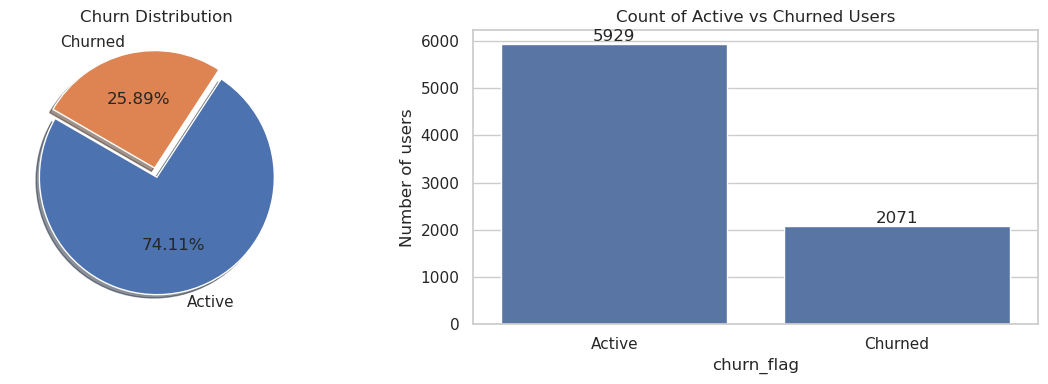

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie chart
axes[0].pie(
    churn_counts,
    labels=["Active", "Churned"],
    autopct="%1.2f%%",
    explode=(0, 0.08),
    shadow=True,
    startangle=150,
)
axes[0].set_title("Churn Distribution")

# Countplot
sns.countplot(
    x="churn_flag",
    data=spotify_df,
    ax=axes[1]
)
axes[1].set_title("Count of Active vs Churned Users")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["Active", "Churned"])
axes[1].set_ylabel("Number of users")

for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%d")

plt.tight_layout()
plt.show()


**Churn by Categorical Features**

In [5]:
cat_features = ["gender", "subscription_type", "device_type", "country", "offline_listening"]

**Churn rate table per Category**

In [6]:
def churn_rate_by_category(df, feature, target="churn_flag"):
    summary = (
        df.groupby(feature)[target]
        .agg(["count", "sum", "mean"])
        .rename(columns={"count": "total_users", "sum": "churned_users", "mean": "churn_rate"})
        .sort_values("churn_rate", ascending=False)
    )
    return summary

for col in cat_features:
    print(f"\n===== {col.upper()} vs CHURN =====")
    display(churn_rate_by_category(spotify_df, col))



===== GENDER vs CHURN =====


,total_users,churned_users,churn_rate
gender,,,
Female,2659,699,0.262881
Other,2650,694,0.261887
Male,2691,678,0.251951



===== SUBSCRIPTION_TYPE vs CHURN =====


,total_users,churned_users,churn_rate
subscription_type,,,
Family,1908,525,0.275157
Student,1959,513,0.261868
Premium,2115,530,0.250591
Free,2018,503,0.249257



===== DEVICE_TYPE vs CHURN =====


,total_users,churned_users,churn_rate
device_type,,,
Mobile,2599,699,0.268950
Desktop,2778,715,0.257379
Web,2623,657,0.250477



===== COUNTRY vs CHURN =====


,total_users,churned_users,churn_rate
country,,,
PK,999,275,0.275275
DE,1015,277,0.272906
FR,989,269,0.271992
AU,1034,266,0.257253
US,1032,262,0.253876
CA,954,237,0.248428
UK,966,239,0.247412
IN,1011,246,0.243323



===== OFFLINE_LISTENING vs CHURN =====


,total_users,churned_users,churn_rate
offline_listening,,,
1,5982,1568,0.262120
0,2018,503,0.249257


**Churn split by subscription type / device / gender / offline**

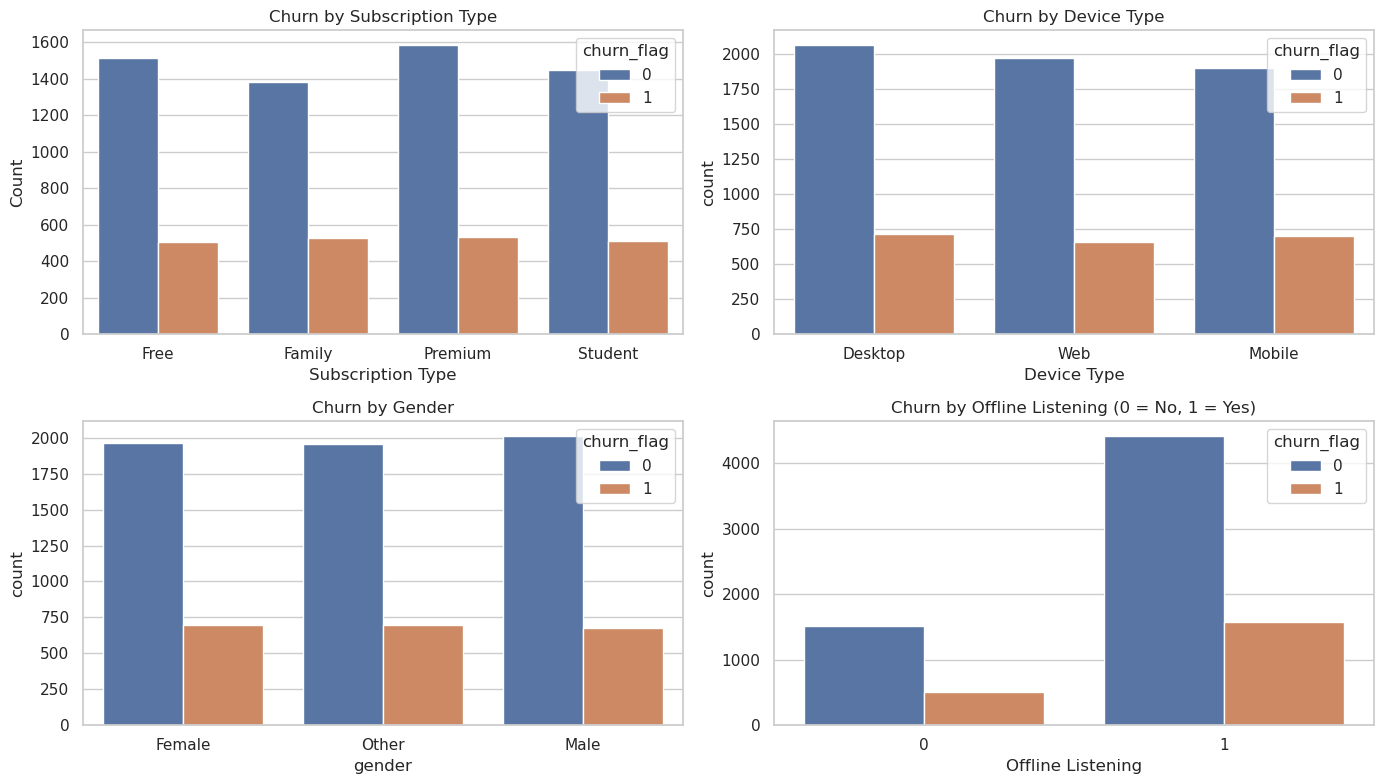

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Subscription type
sns.countplot(
    x="subscription_type",
    hue="churn_flag",
    data=spotify_df,
    ax=axes[0, 0]
)
axes[0, 0].set_title("Churn by Subscription Type")
axes[0, 0].set_xlabel("Subscription Type")
axes[0, 0].set_ylabel("Count")

# Device type
sns.countplot(
    x="device_type",
    hue="churn_flag",
    data=spotify_df,
    ax=axes[0, 1]
)
axes[0, 1].set_title("Churn by Device Type")
axes[0, 1].set_xlabel("Device Type")

# Gender
sns.countplot(
    x="gender",
    hue="churn_flag",
    data=spotify_df,
    ax=axes[1, 0]
)
axes[1, 0].set_title("Churn by Gender")

# Offline listening
sns.countplot(
    x="offline_listening",
    hue="churn_flag",
    data=spotify_df,
    ax=axes[1, 1]
)
axes[1, 1].set_title("Churn by Offline Listening (0 = No, 1 = Yes)")
axes[1, 1].set_xlabel("Offline Listening")

plt.tight_layout()
plt.show()


**Statistical Association: Categorical Features vs Churn (Chi-Square)**

In [10]:
def chi_square_test(df, cat_col, target_col="churn_flag"):
    ctab = pd.crosstab(df[cat_col], df[target_col])
    chi2, p, dof, expected = chi2_contingency(ctab)
    print(f"Chi-square test: {cat_col} vs {target_col}")
    print(f"chi2 = {chi2:.3f}, dof = {dof}, p-value = {p:.6f}")
    if p < 0.05:
        print("→ Statistically significant association.")
    else:
        print("→ No statistically significant association.")
    return chi2, p, dof, expected

for col in cat_features:
    print("\n" + "="*60)
    chi_square_test(spotify_df, col, "churn_flag")



Chi-square test: gender vs churn_flag
chi2 = 1.020, dof = 2, p-value = 0.600461
→ No statistically significant association.

Chi-square test: subscription_type vs churn_flag
chi2 = 4.458, dof = 3, p-value = 0.216111
→ No statistically significant association.

Chi-square test: device_type vs churn_flag
chi2 = 2.372, dof = 2, p-value = 0.305498
→ No statistically significant association.

Chi-square test: country vs churn_flag
chi2 = 5.956, dof = 7, p-value = 0.544858
→ No statistically significant association.

Chi-square test: offline_listening vs churn_flag
chi2 = 1.235, dof = 1, p-value = 0.266412
→ No statistically significant association.


**Numeric Features vs Churn**

In [12]:
numeric_features = [
    "age",
    "listening_time",
    "songs_played_per_day",
    "skip_rate",
    "ads_listened_per_week",
]


**Boxplots: distribution by churn**

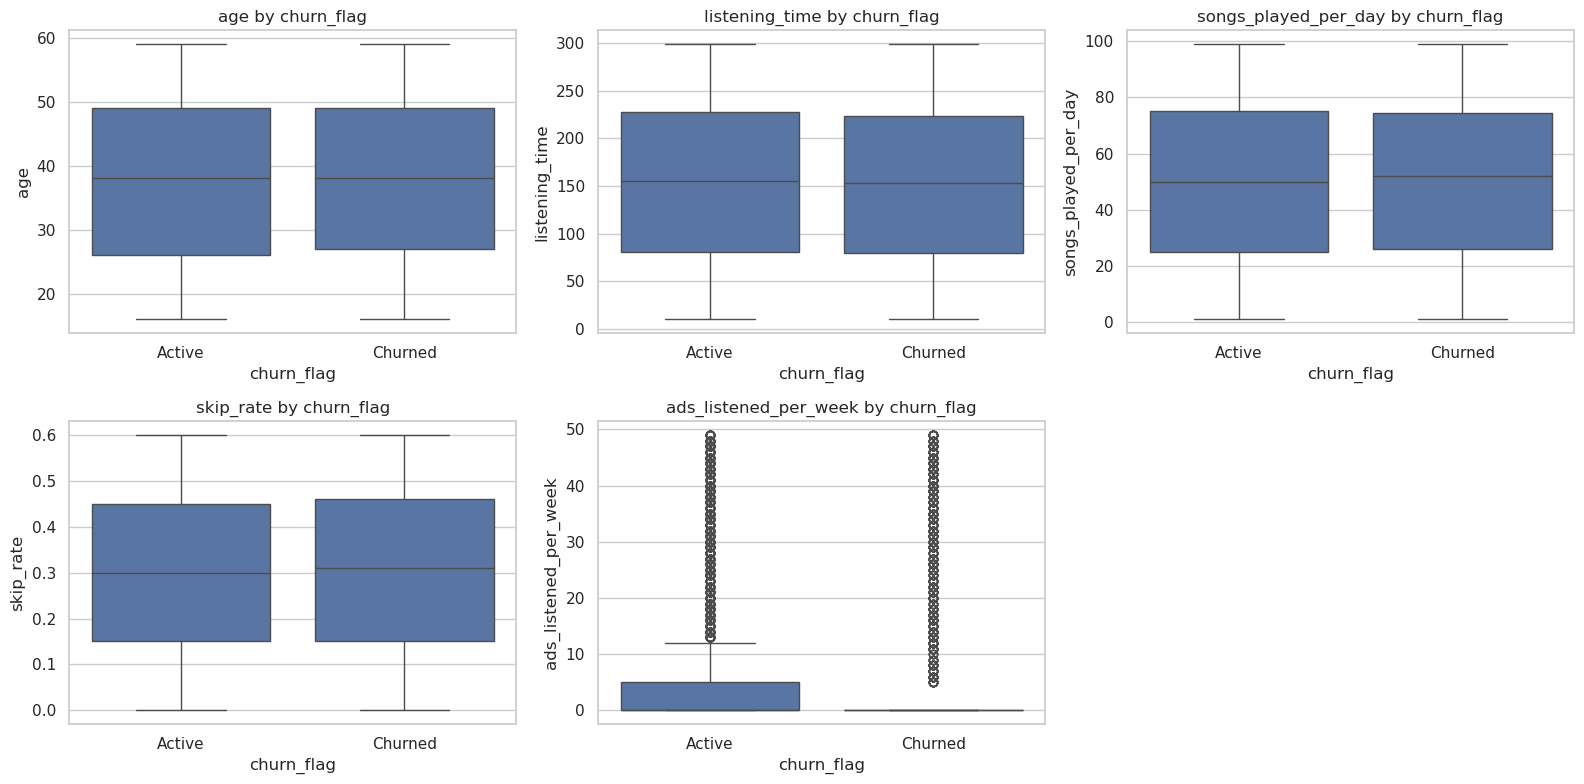

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.boxplot(
        x="churn_flag",
        y=col,
        data=spotify_df,
        ax=axes[i]
    )
    axes[i].set_title(f"{col} by churn_flag")
    axes[i].set_xticklabels(["Active", "Churned"])

for j in range(len(numeric_features), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


**Normality Check (Skew/Kurtosis) per Churn Group**

In [15]:
def check_normality_by_group(df, num_col, target_col="churn_flag"):
    rows = []
    for grp, subset in df.groupby(target_col):
        data = subset[num_col].dropna()
        sk = skew(data)
        kt = kurtosis(data)
        rows.append({"group": grp, "skew": sk, "kurtosis": kt})
    return pd.DataFrame(rows)

for col in numeric_features:
    print("\n" + "="*80)
    print(f"Normality check for: {col}")
    display(check_normality_by_group(spotify_df, col, "churn_flag"))



Normality check for: age


,group,skew,kurtosis
0,0,-0.029789,-1.214722
1,1,-0.020249,-1.200969



Normality check for: listening_time


,group,skew,kurtosis
0,0,0.000985,-1.223606
1,1,0.034501,-1.184608



Normality check for: songs_played_per_day


,group,skew,kurtosis
0,0,0.007193,-1.195851
1,1,-0.034732,-1.179533



Normality check for: skip_rate


,group,skew,kurtosis
0,0,0.018039,-1.182249
1,1,-0.029267,-1.226440



Normality check for: ads_listened_per_week


,group,skew,kurtosis
0,0,1.793502,1.793250
1,1,1.815871,1.836657


**Mann–Whitney U Test: Numeric vs Churn**

In [16]:
def mann_whitney_test(df, num_col, target_col="churn_flag"):
    groups = df[target_col].dropna().unique()
    if len(groups) != 2:
        raise ValueError("Mann–Whitney U requires exactly 2 groups.")

    g1, g2 = groups
    x1 = df[df[target_col] == g1][num_col].dropna()
    x2 = df[df[target_col] == g2][num_col].dropna()

    stat, p = mannwhitneyu(x1, x2, alternative="two-sided")
    print(f"Mann–Whitney U test for {num_col} by {target_col}")
    print(f"U = {stat:.3f}, p-value = {p:.6f}")
    if p < 0.05:
        print("→ Significant difference between churn groups.")
    else:
        print("→ No significant difference between churn groups.")
    return stat, p

for col in numeric_features:
    print("\n" + "="*80)
    mann_whitney_test(spotify_df, col, "churn_flag")



Mann–Whitney U test for age by churn_flag
U = 6170077.500, p-value = 0.735175
→ No significant difference between churn groups.

Mann–Whitney U test for listening_time by churn_flag
U = 6078200.500, p-value = 0.498248
→ No significant difference between churn groups.

Mann–Whitney U test for songs_played_per_day by churn_flag
U = 6215876.000, p-value = 0.398464
→ No significant difference between churn groups.

Mann–Whitney U test for skip_rate by churn_flag
U = 6269757.500, p-value = 0.149862
→ No significant difference between churn groups.

Mann–Whitney U test for ads_listened_per_week by churn_flag
U = 6080982.000, p-value = 0.396709
→ No significant difference between churn groups.


**Grouped Summary Table by Churn**

In [17]:
group_summary = (
    spotify_df.groupby("churn_flag")[numeric_features]
    .agg(["mean", "median", "std", "min", "max"])
)
group_summary


age                           listening_time         \
                 mean median        std min max           mean median   
churn_flag                                                              
0           37.632147   38.0  12.763331  16  59     154.446787  155.0   
1           37.747948   38.0  12.677044  16  59     152.984549  153.0   

                                ... skip_rate                             \
                  std min  max  ...      mean median       std  min  max   
churn_flag                      ...                                        
0           84.323276  10  299  ...  0.298474   0.30  0.173328  0.0  0.6   
1           83.139146  10  299  ...  0.304862   0.31  0.174310  0.0  0.6   

           ads_listened_per_week                            
                            mean median        std min max  
churn_flag                                                  
0                       6.962220    0.0  13.581398   0  49  
1                       6.891357    0.0  13.725229   0  49  

[2 rows x 25 columns]